In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
import shap
shap.initjs()

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data = data.data, columns = data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
X = df.drop('target', axis = 1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify = y)

In [4]:
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [5]:
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred_prob[0:5]

array([3.9324630e-04, 9.9975067e-01, 6.8189664e-04, 4.1078201e-01,
       3.4063956e-04], dtype=float32)

In [6]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy Score:", acc)

Accuracy Score: 0.956140350877193


In [7]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [8]:
auc = roc_auc_score(y_test, y_pred_prob)  # UŻYWAJ prawdopodobieństw, nie klas!
print("ROC AUC:", auc)

ROC AUC: 0.9927248677248677


In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[38  4]
 [ 1 71]]


In [34]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance)

                    Feature  Importance
20             worst radius    0.518930
22          worst perimeter    0.167894
27     worst concave points    0.073234
11            texture error    0.042075
7       mean concave points    0.031116
25        worst compactness    0.024513
23               worst area    0.016333
3                 mean area    0.014767
21            worst texture    0.014444
14         smoothness error    0.012645
1              mean texture    0.012262
26          worst concavity    0.010990
10             radius error    0.010543
13               area error    0.008429
24         worst smoothness    0.007168
4           mean smoothness    0.006949
19  fractal dimension error    0.005510
16          concavity error    0.004407
29  worst fractal dimension    0.003160
28           worst symmetry    0.002901
15        compactness error    0.002677
9    mean fractal dimension    0.002497
5          mean compactness    0.001591
6            mean concavity    0.001384


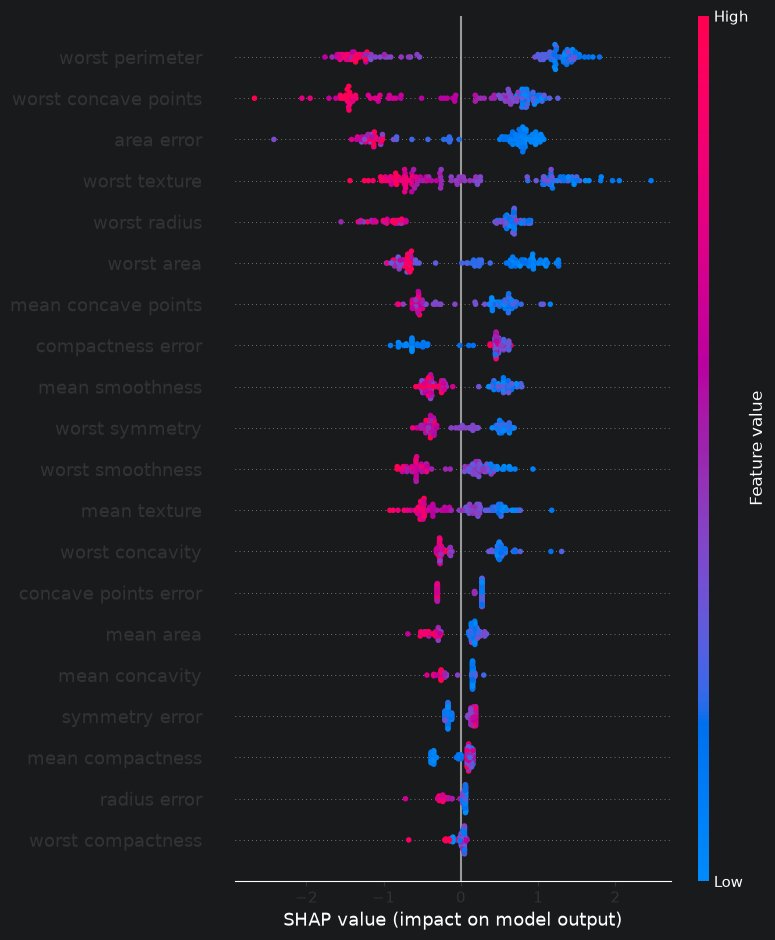

In [23]:
tree = shap.TreeExplainer(model)
shap_values_tree = tree.shap_values(X_test)
shap.summary_plot(shap_values_tree, X_test)

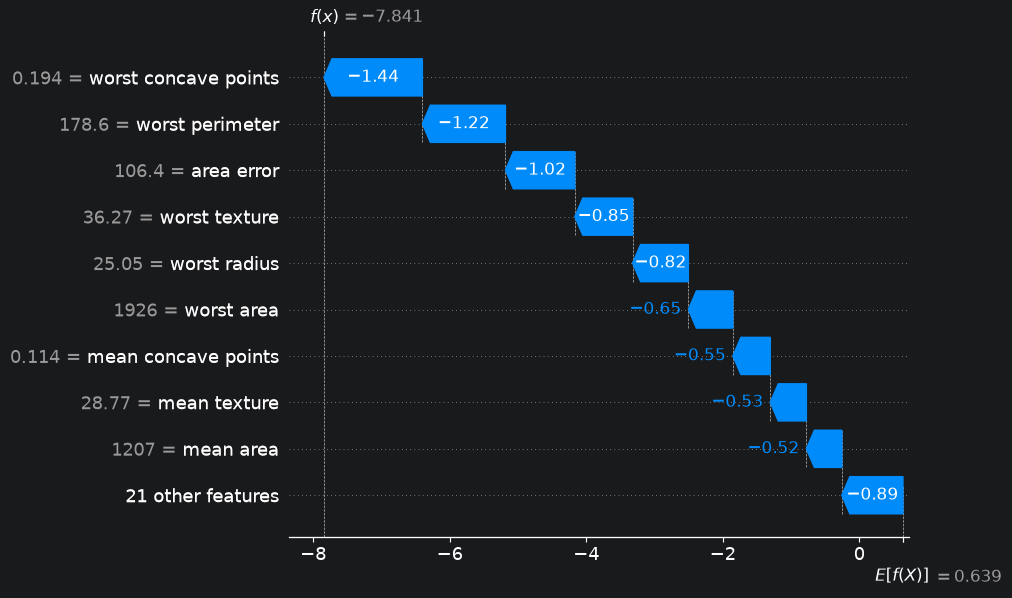

In [29]:
explanation = tree(X_test)
shap.waterfall_plot(explanation[0])

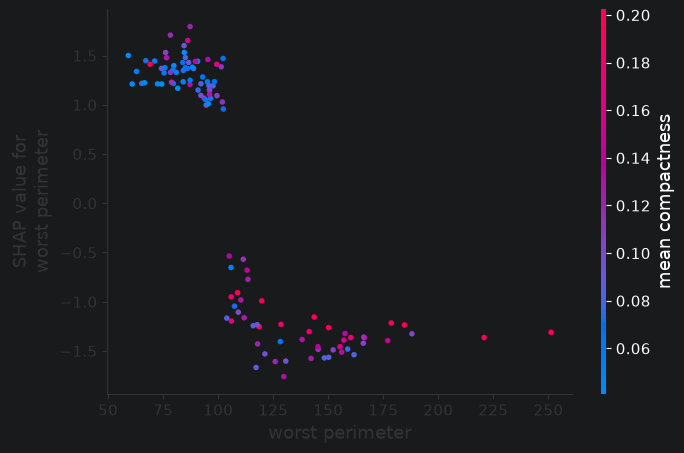

In [35]:
shap.dependence_plot("worst perimeter", shap_values_tree, X_test)